# Income Level Prediction

This notebook loads the provided census income dataset, preprocesses the features, trains a scikit-learn model, and evaluates its performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [2]:
# Load Dataset

data_path = 'income_data.csv'
df_raw = pd.read_csv(data_path)
df = df_raw.copy()

display(df.head())
print('\nDataset shape:', df.shape)
print('\nData types:')
print(df.dtypes)
print('\nMissing values by column:')
print(df.isna().sum())
print('\nValue counts for income target:')
print(df['income'].value_counts(dropna=False))
print('\nUnique category counts:')
print(df.select_dtypes(include='object').nunique())


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



Dataset shape: (48842, 15)

Data types:
age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

Missing values by column:
age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

Value counts for income target:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Unique category counts:
workclass          9
education         16
marital-status     7
occupation      

## Exploratory Data Analysis

The following analysis uses visualizations to identify patterns that will guide preprocessing and feature selection. The plots focus on the target distribution, numeric variables, and key categorical predictors such as education and workclass.

Missing values after placeholder replacement:
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
income_label         0
dtype: int64


C:\Users\OMEN\AppData\Local\Temp\ipykernel_16972\157629199.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_plot, x='income_label', palette='pastel', ax=axes[0, 0])
C:\Users\OMEN\AppData\Local\Temp\ipykernel_16972\157629199.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='income_label', y='hours-per-week', palette='pastel', ax=axes[1, 0])


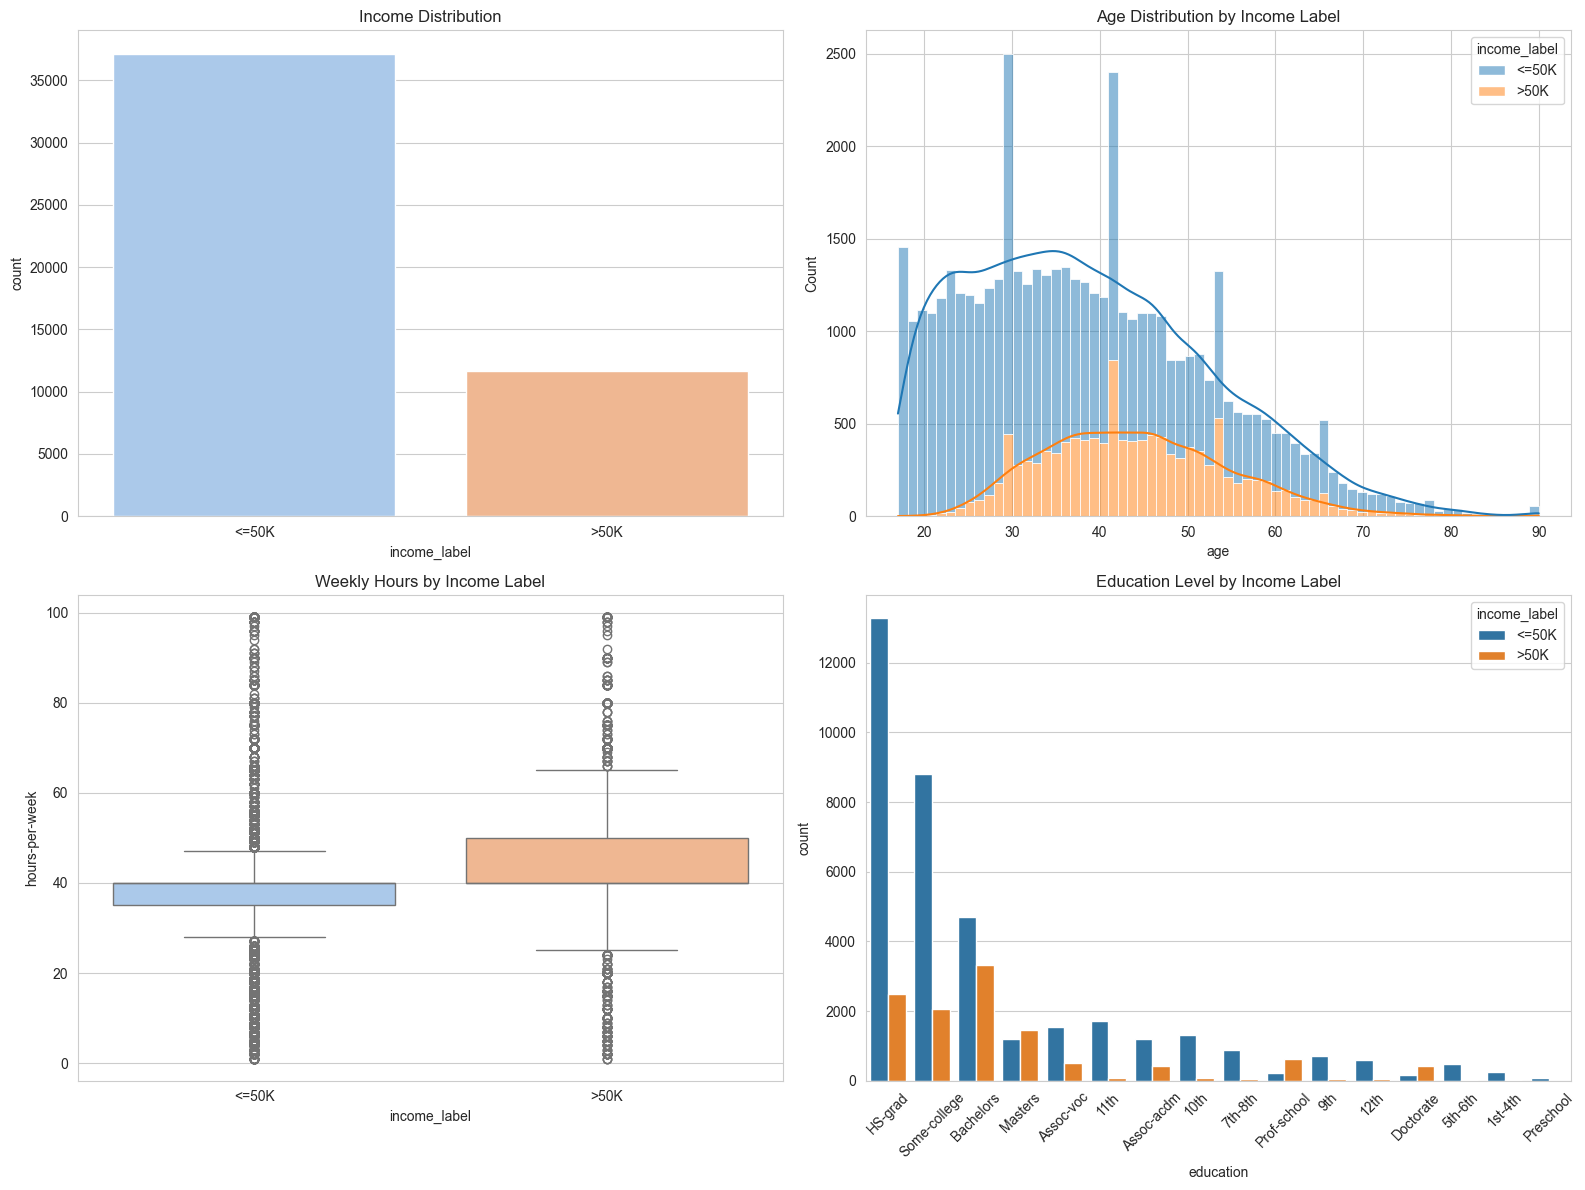

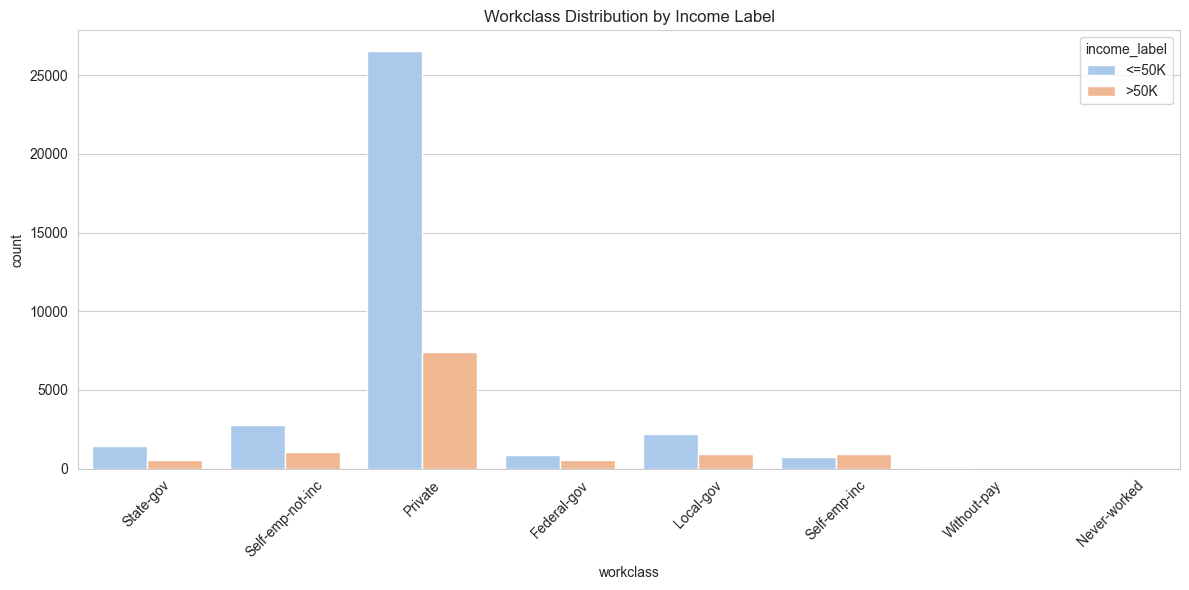


Numeric summary statistics for key features:
                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  48842.000000  4.884200e+04   48842.000000  48842.000000  48842.000000   
mean      38.643585  1.896641e+05      10.078089   1079.067626     87.502314   
std       13.710510  1.056040e+05       2.570973   7452.019058    403.004552   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.175505e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.781445e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.376420e+05      12.000000      0.000000      0.000000   
max       90.000000  1.490400e+06      16.000000  99999.000000   4356.000000   

       hours-per-week  
count    48842.000000  
mean        40.422382  
std         12.391444  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


In [3]:
# Exploratory Data Analysis

df_plot = df.copy()
df_plot.replace('?', np.nan, inplace=True)

df_plot['income_label'] = df_plot['income'].astype('category')
print('Missing values after placeholder replacement:')
print(df_plot.isna().sum())

# Plot target distribution and numeric trends
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.countplot(data=df_plot, x='income_label', palette='pastel', ax=axes[0, 0])
axes[0, 0].set_title('Income Distribution')

sns.histplot(data=df_plot, x='age', hue='income_label', kde=True, multiple='stack', ax=axes[0, 1])
axes[0, 1].set_title('Age Distribution by Income Label')

sns.boxplot(data=df_plot, x='income_label', y='hours-per-week', palette='pastel', ax=axes[1, 0])
axes[1, 0].set_title('Weekly Hours by Income Label')

order = df_plot['education'].value_counts().index
sns.countplot(data=df_plot, x='education', hue='income_label', order=order, ax=axes[1, 1])
axes[1, 1].set_title('Education Level by Income Label')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Workclass vs income distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=df_plot[df_plot['workclass'].notna()], x='workclass', hue='income_label', palette='pastel')
plt.title('Workclass Distribution by Income Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Correlation of numeric features with target after encoding numeric values
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
print('\nNumeric summary statistics for key features:')
print(df_plot[numeric_cols].describe())


## Preprocessing Decisions

The EDA plots show that income is not evenly distributed across age groups, education levels, workclass categories, and weekly hours. These relationships justify:

- keeping numeric variables such as `age`, `education-num`, `hours-per-week`, and the capital gain/loss features,
- encoding categorical variables with one-hot encoding,
- scaling numeric features before tree-based training for consistency and interpretability,
- dropping rows with sparse placeholder values after confirming that there are relatively few missing values.


In [4]:
# Preprocess Data

# Copy the original dataset so the raw version remains available for review

df = df_raw.copy()

# Replace the placeholder string '?' with NaN and inspect how many rows are affected.
df.replace('?', np.nan, inplace=True)
print('Missing values after placeholder replacement:')
print(df.isna().sum())

# Drop rows with missing values only after exploring their frequency and confirming they are a small share of the dataset.
df.dropna(inplace=True)
print('\nShape after dropping missing rows:', df.shape)

# Map the target to numeric for modeling
X = df.drop('income', axis=1)
y = df['income'].map({'<=50K': 0, '>50K': 1})

numeric_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
category_features = [col for col in X.columns if col not in numeric_features]
print('\nNumeric features:', numeric_features)
print('Categorical features:', category_features)

# The EDA suggests that categorical factors such as education, workclass, and marital status are meaningful for income prediction.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), category_features)
    ]
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])


Missing values after placeholder replacement:
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64

Shape after dropping missing rows: (45222, 15)

Numeric features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [5]:
# Split Data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set shape:', X_train.shape)
print('Test set shape:', X_test.shape)
print('Positive class ratio in y_test:', y_test.mean())

Training set shape: (36177, 14)
Test set shape: (9045, 14)
Positive class ratio in y_test: 0.2478717523493643


In [6]:
# Train Scikit-learn Model

pipeline.fit(X_train, y_train)

model_filename = 'income_classifier.joblib'
joblib.dump(pipeline, model_filename)
print(f'Model saved to {model_filename}')

Model saved to income_classifier.joblib


In [7]:
# Evaluate Model

predictions = pipeline.predict(X_test)
pred_probs = pipeline.predict_proba(X_test)[:, 1]

print('Accuracy:', accuracy_score(y_test, predictions))
print('Precision:', precision_score(y_test, predictions))
print('Recall:', recall_score(y_test, predictions))
print('F1 score:', f1_score(y_test, predictions))
print('ROC AUC:', roc_auc_score(y_test, pred_probs))
print('\nConfusion matrix:')
print(confusion_matrix(y_test, predictions))
print('\nClassification report:')
print(classification_report(y_test, predictions, target_names=['<=50K', '>50K']))

Accuracy: 0.852294085129906
Precision: 0.7417289220917823
Recall: 0.6199821587867975
F1 score: 0.6754130223517979
ROC AUC: 0.9038173587425289

Confusion matrix:
[[6319  484]
 [ 852 1390]]

Classification report:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      6803
        >50K       0.74      0.62      0.68      2242

    accuracy                           0.85      9045
   macro avg       0.81      0.77      0.79      9045
weighted avg       0.85      0.85      0.85      9045

